# Performance Profiles of Different Methods
## Load Data

In [2]:
import pandas as pd
from pathlib import Path

# go up from notebook → project root
ROOT = Path().resolve().parents[2]

# DATA_PATH = ROOT / "src" / "data" / "MyData" / "DiverseNAS Method Baselines - Performance Ratios.csv"
DATA_PATH = ROOT / "src" / "data" / "MyData" / "DiverseNAS Method Baselines - CutDown.csv"

df = pd.read_csv(DATA_PATH)


In [3]:
df.head()
# df.columns

,Paper,Method,Spherical,NinaPro,ECG,Satellite
0,MP-NAS,Expert,1.397678,1.322727,1.000000,1.612378
1,MP-NAS,Rand. Pred.,1.420900,1.548485,1.142857,1.136808
2,MP-NAS,MP-1NAS,1.335269,1.104545,1.142857,1.031759
3,DASH,WRN,1.778354,1.027273,1.535714,1.261401
4,DASH,Expert,1.397678,1.322727,1.000000,1.612378


# Per Paper

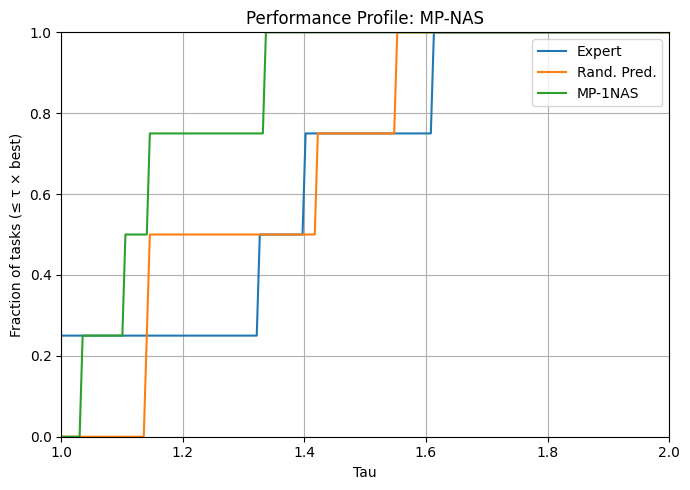

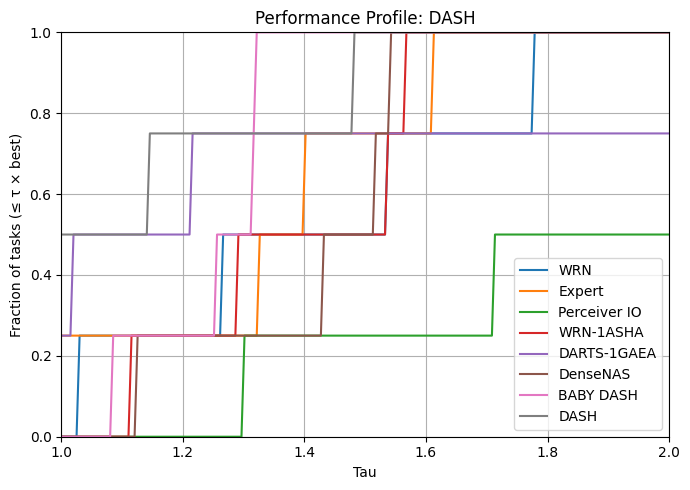

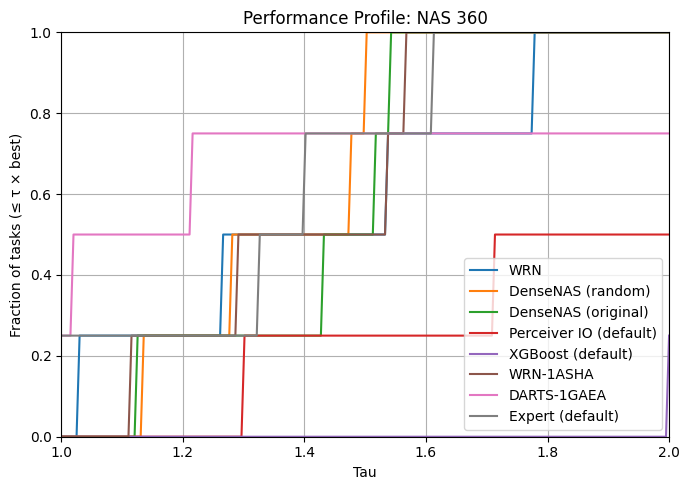

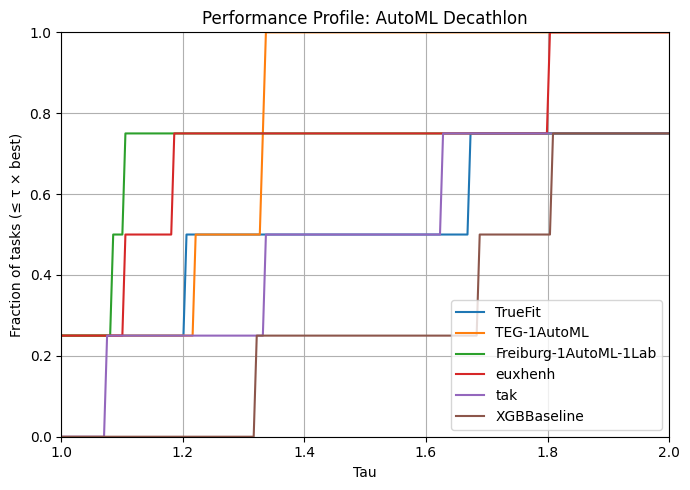

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- PREP ----
task_cols = df.columns[2:]  # skip Paper, Method

# replace -1 with NaN
df[task_cols] = df[task_cols].replace(-1, np.nan)

taus = np.arange(0, 10.1, 0.1)

# ---- FUNCTION ----
def compute_profiles(sub_df):
    profiles = {}

    for _, row in sub_df.iterrows():
        method = row["Method"]
        values = row[task_cols].dropna().values
        values = values[values >= 0]
        if len(values) == 0:
            continue

        perf = []
        for tau in taus:
            perf.append(np.mean(values <= tau))

        profiles[method] = perf

    return pd.DataFrame(profiles, index=taus)

# ---- PLOT PER PAPER ----
papers = df["Paper"].unique()

# Max tau per paper
# max_tau_per_paper = {}

# for paper in papers:
#     sub_df = df[df["Paper"] == paper]

#     values = sub_df.iloc[:, 2:].values.flatten()
#     values = values[~np.isnan(values)]  # remove NaN
#     values = values[values >= 0]        # remove -1

#     max_tau = values.max()
#     max_tau_per_paper[paper] = max_tau
max_tau_per_paper = {
    "MP-NAS": 2,
    "DASH": 2,
    "NAS 360": 2,
    "AutoML Decathlon": 2
}


for paper in papers:
    sub_df = df[df["Paper"] == paper]

    max_tau = max_tau_per_paper[paper]
    taus = np.linspace(1, max_tau, 200)

    profiles_df = compute_profiles(sub_df)

    plt.figure(figsize=(7,5))

    for method in profiles_df.columns:
        plt.plot(taus, profiles_df[method], label=method)

    plt.title(f"Performance Profile: {paper}")
    plt.xlabel("Tau")
    plt.ylabel("Fraction of tasks (≤ τ × best)")
    plt.xlim(1, max_tau)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ALL

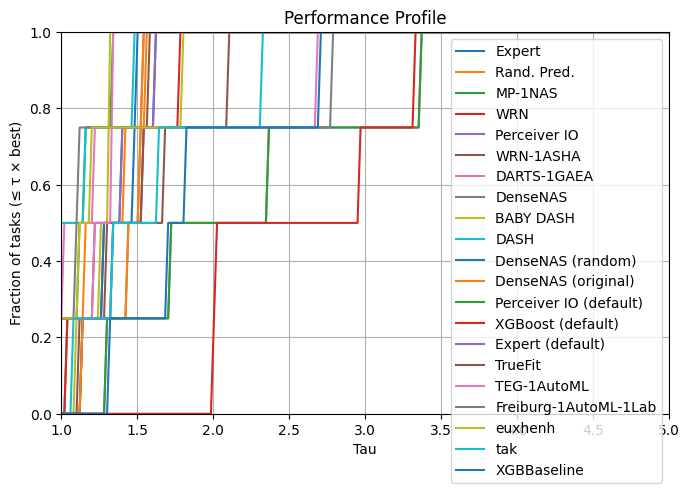

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- PREP ----
task_cols = ["Spherical", "NinaPro", "ECG", "Satellite"]

df[task_cols] = df[task_cols].replace(-1, np.nan)
tauMax=5
taus = np.linspace(1, tauMax, 200)

# ---- COMPUTE ----
profiles = {}

for _, row in df.iterrows():
    method = row["Method"]
    values = row[task_cols].dropna().values

    perf = [np.mean(values <= tau) for tau in taus]
    profiles[method] = perf

profiles_df = pd.DataFrame(profiles, index=taus)

# ---- PLOT ----
plt.figure(figsize=(7,5))

for method in profiles_df.columns:
    plt.plot(taus, profiles_df[method], label=method)

plt.xlabel("Tau")
plt.ylabel("Fraction of tasks (≤ τ × best)")
plt.title("Performance Profile")
plt.xlim(1, tauMax)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Area Under Curve
Above is too crowded. Just look at top K. Score is decided by Area Under Profile

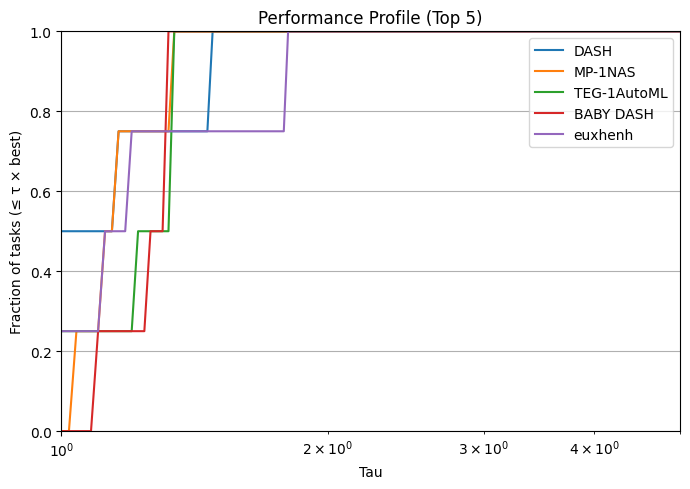

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- PREP ----
task_cols = ["Spherical", "NinaPro", "ECG", "Satellite"]

df[task_cols] = df[task_cols].replace(-1, np.nan)

tauMax = 5
taus = np.linspace(1, tauMax, 200)

# ---- COMPUTE ----
profiles = {}

for _, row in df.iterrows():
    method = row["Method"]
    values = row[task_cols].dropna().values

    if len(values) == 0:
        continue

    perf = [np.mean(values <= tau) for tau in taus]
    profiles[method] = perf

profiles_df = pd.DataFrame(profiles, index=taus)

# ---- COMPUTE AUP (log scale) ----
log_tau = np.log10(taus)

aup_scores = {}
for method in profiles_df.columns:
    y = profiles_df[method].values
    aup = np.trapezoid(y, log_tau)
    aup_scores[method] = aup

# ---- GET TOP 5 ----
top5 = sorted(aup_scores, key=aup_scores.get, reverse=True)[:5]

# ---- PLOT ----
plt.figure(figsize=(7,5))

for method in top5:
    plt.plot(taus, profiles_df[method], label=method)

plt.xlabel("Tau")
plt.ylabel("Fraction of tasks (≤ τ × best)")
plt.title("Performance Profile (Top 5)")
plt.xscale("log")   # important
plt.xlim(1, tauMax)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()